# Credit Risk Models

Works through single-name and portfolio credit risk: structural default
modeling, hazard rates implied from CDS quotes, rating-migration bond
valuation with a crisis stress, and correlated-default pricing of basket
tranches.

| Section | Topic | Methods |
|---|---|---|
| 3.1 | Structural default risk | Merton model solved for asset value and volatility, risk-neutral default probability, market spread, implied recovery |
| 3.2 | CDS pricing | Hazard rates bootstrapped from a CDS curve, mark-to-market of a seasoned 200bp contract, par binary CDS spread |
| 3.3 | Rating migrations | Markov chain on a transition matrix, expected bond value under migrations and default, GFC stress with its own matrix and LGD |
| 3.4 | Basket tranches | One-factor Gaussian correlated defaults, tranche waterfall, Monte Carlo pricing of three tranches |
| 3.5 | Loss distributions | Simulated portfolio losses against the Vasicek asymptotic distribution, fixed vs Beta(0.5, 0.5) recovery |

All inputs are set inline and the notebook runs top to bottom with no
external data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import norm, beta
from scipy.optimize import minimize
from scipy.optimize import fsolve


## 3.1 Merton's Structural Model

- Equity Value:  $\quad E = 100$
- Equity Volatility: $\quad σ_E = 40\%$
- Debt Face Value: $\quad D = 150$
- Debt Maturity: $\quad T = 5 \text{ years}$
- Risk-Free Rate: $\quad r_f = 3\%$



#### a) Use Merton’s model to find the asset value and asset volatility?

We observe equity value $E$ and equity volatility $\sigma_E$. Find asset value $V$ and asset volatility $\sigma_V$ by solving the nonlinear system:


$$\begin{cases} E = V N(d_1) - D e^{-r_f T} N(d_2) \quad (1) \\[6pt] \sigma_E = \dfrac{V}{E} N(d_1) \sigma_V  \qquad \qquad \qquad (2) \end{cases} \quad  \, $$
where
$$d_1 = \frac{\ln(V/D) + (r_f + \frac{1}{2}\sigma_V^2)\, T}{\sigma_V \sqrt{T}}, \qquad d_2 = d_1 - \sigma_V\sqrt{T}$$
**(1)** Equity is a call option on firm assets $V$ with strike $D$, priced via Black-Scholes

**(2)** Equity volatility is linked to asset volatility through the option delta $N(d_1)$


Since the Merton system is nonlinear in $V$ and $\sigma_V$, it has no closed-form
solution and we must use numerical methods. We reframe this as a **minimization problem** for numerical robustness, minimizing the Euclidean distance between model-implied and observed quantities:

$$\text{Objective}(V,\sigma_V) = \sqrt{\left(E^{\text{implied}}-E\right)^2 + \left(\sigma_E^{\text{implied}}-\sigma_E\right)^2}$$

When the objective reaches zero, both equations are satisfied.

In [2]:
E  = 100
vol_E = 0.4
D  = 150
T  = 5
rf = 0.03

def merton_sys(V, vol_V):
    d1 = (np.log(V/D) + (rf + 0.5*vol_V**2)*T) / (vol_V*np.sqrt(T))
    d2 = d1 - vol_V*np.sqrt(T)
    E_imp = V*norm.cdf(d1) - D*np.exp(-rf*T)*norm.cdf(d2)
    vol_E_imp = (V/E)*norm.cdf(d1)*vol_V
    return E_imp, vol_E_imp, d2

def objective(param):
    V, vol_V = param
    E_imp, vol_E_imp, _ = merton_sys(V, vol_V)
    return np.sqrt((E_imp - E)**2 + (vol_E_imp - vol_E)**2)

result = minimize(objective, x0=[200, 0.20])
V, vol_V = result.x

print(f"Asset Value (V)  = {V:.2f}")
print(f"Asset Volatility (sigma_V) = {vol_V:.3%}")

Asset Value (V)  = 226.07
Asset Volatility (sigma_V) = 18.861%


#### b) What is the risk-neutral probability of default over the debt’s maturity and the annualized default probability?
Risk-neutral probability of default is  probability that firm assets fall below debt face value at maturity:

$$PD_{RN}(0,T) = P(V_T < D)  = N(-d_2)$$

Annualized default probability is implied by the cumulative $PD$, as if risk were spread evenly across each year:

$$\overline{PD} = 1 - (1 - PD^{RN}(0,T))^{1/T}$$

In [3]:
_, _, d2 = merton_sys(V, vol_V)

PD_rn = norm.cdf(-d2)
PD_rn_annual = 1 - (1 - PD_rn)**(1/T)

print(f"PD_RN(0,T) = {PD_rn:.3%}")
print(f"PD_RN_annual = {PD_rn_annual:.3%}")

PD_RN(0,T) = 13.191%
PD_RN_annual = 2.789%


#### c) What is the market spread for the debt?

$$\text{The market value of debt:} \qquad B = V - E$$

The implied credit spread $s$  is the extra yield above risk-free that makes the bond price equal to its market value:

$$B = D e^{-(r+s)T} \implies s = -\frac{1}{T}\ln\!\left(\frac{B}{D}\right) - r$$

In [4]:
B = V - E
s = -np.log(B/D)/T - rf
print(f"Market value of debt = {B:.2f}")
print(f"Market Credit Spread = {s:.3%}")

Market value of debt = 126.07
Market Credit Spread = 0.477%


#### d) What is the implied Recovery Rate?

Risk-free present value of debt is:

$$PV_{rf} = D e^{-rT}$$

Expected loss is the gap between the risk-free and risky debt values, as a fraction of the risk-free value:

$$E[Loss] = \frac{PV_{rf} - B}{PV^{rf}}$$

Implied recovery rate is then backed out from the relationship
$\quad E[Loss]  = PD_{RN}(0,T) \cdot (1 - RR)$:

$$RR = 1 - \frac{EL}{PD^{RN}(0,T)}$$

In [5]:
PV_rf = D * np.exp(-rf*T)
EL    = (PV_rf - B) / PV_rf
RR    = 1 - EL/PD_rn

print(f"Risk-free PV of Debt = {PV_rf:.2f}")
print(f"Expected Loss = {EL:.3%}")
print(f"Implied RR = {RR:.3%}")

Risk-free PV of Debt = 129.11
Expected Loss = 2.355%
Implied RR = 82.147%


## 3.2 CDS Pricing & Bootstrapping

- Risk-free rate: $\quad r_f = 5\%$ (flat, continuously compounded)
- Recovery Rate: $\quad RR = 40\%$

| Tenor | CDS Spread |
|-------|-----------|
| 1     | 1.0%      |
| 2     | 1.2%      |
| 3     | 1.4%      |
| 4     | 1.6%      |
| 5     | 1.7%      |



#### a) What are the risk neutral default probabilities for each year?
Let:
- $V(t)$: survival probability to payment date $t$
- $PD(t) = Q_t \times V(t-1)$ :  unconditional default probability in period $t$
- $\alpha = 0.5$: fraction of period elapsed before default (midpoint assumption)
- $DF(t)$: risk-free discount factor to payment date $t = e^{-r_f t}$
- $DF(t^*)$: risk-free discount factor to mid-period default date $= e^{-r_f(t-0.5)}$

$$\text{CDS Value} = \text{Premium Leg} + \text{Accrual Leg} - \text{Default Leg}$$

**Set CDS Value = 0 and solve for $Q_t$:**

$$\underbrace{s_t \cdot \sum_{i=1}^{t} V(i) \cdot DF(i)}_{\text{Premium Leg}} + \underbrace{s_t \cdot \sum_{i=1}^{t} PD(i) \cdot 0.5 \cdot DF(i^*)}_{\text{Accrual Leg}} - \underbrace{\sum_{i=1}^{t} PD(i) \cdot (1-RR) \cdot DF(i^*)}_{\text{Default Leg}} = 0$$

**Such that:**

$DF(t) = e^{-r_f t} \quad \text{and} \quad DF(t^*) = e^{-r_f(t-0.5)}$

$V(t) = (1-Q_t) \cdot V(t-1) \quad \text{with} \quad V(0) = 1$

$PD(t) = Q_t \cdot V(t-1)$

At each tenor $t$, all quantities for $i < t$ are known, leaving only $Q_t$ as unknown.


In [6]:
rf = 0.05
RR = 0.40
T = 5
s = [0.010, 0.012, 0.014, 0.016, 0.017]

Q  = np.zeros(T)
V  = np.zeros(T+1)
PD = np.zeros(T)
V[0] = 1.0

def DF(t):
    return np.exp(-rf * t)

def DF_def(t):
    return np.exp(-rf * (t - 0.5))

def cds_equ(Q_t, t, s_t):
    V_t = (1 - Q_t) * V[t-1]
    PD_t = Q_t * V[t-1]

    hist_prem = sum(V[i] * DF(i) for i in range(1, t))
    hist_accr = sum(PD[i-1] * 0.5 * DF_def(i)    for i in range(1, t))
    hist_loss = sum(PD[i-1] * (1-RR) * DF_def(i) for i in range(1, t))

    prem = s_t * (hist_prem + V_t * DF(t))
    accr = s_t * (hist_accr + PD_t * 0.5 * DF_def(t))
    loss = (hist_loss + PD_t * (1-RR) * DF_def(t))

    return prem + accr - loss

for t in range(1, T + 1):
    s_t = s[t-1]
    Q_t = fsolve(cds_equ, x0=0.02, args=(t, s_t))[0]
    Q[t-1]  = Q_t
    V[t]    = (1 - Q_t) * V[t-1]
    PD[t-1] = Q_t * V[t-1]

df = pd.DataFrame({
    'Tenor'     : range(1, T+1),
    'CDS Spread': [f"{s_t:.1%}" for s_t in s],
    'Q_t'       : [f"{q:.3%}"  for q in Q],
    'V(t)'      : [f"{v:.3%}"  for v in V[1:]],
    'PD(t)'     : [f"{p:.3%}"  for p in PD],
})

display(df.style.hide())

Tenor,CDS Spread,Q_t,V(t),PD(t)
1,1.0%,1.613%,98.387%,1.613%
2,1.2%,2.274%,96.150%,2.237%
3,1.4%,2.959%,93.305%,2.846%
4,1.6%,3.678%,89.873%,3.431%
5,1.7%,3.503%,86.725%,3.149%


#### b) What is the value of an existing 5-year CDS with a 200bp spread?


An existing CDS with spread $s^* = 200 \text{bp}$ differs from the par spread $s^{\text{par}} = 170 \text{bp}$.

$$\text{CDS Value} = \underbrace{s^* \cdot \sum_{t=1}^{5} V(t) \cdot P(t)}_{\text{Premium Leg}} + \underbrace{s^* \cdot \sum_{t=1}^{5} PD(t) \cdot 0.5 \cdot P(t^*)}_{\text{Accrual Leg}} - \underbrace{\sum_{t=1}^{5} PD(t) \cdot (1-RR) \cdot P(t^*)}_{\text{Default Leg}}$$

where $V(t)$, $PD(t)$, $P(t)$, $P(t^*)$ are already known from part (a), hence plug in $s^* = 0.02$ instead of solving for $Q_t$.



In [7]:
s_exist = 0.02

prem = s_exist * sum(V[t] * DF(t) for t in range(1, T+1))
accr = s_exist * sum(PD[t-1] * 0.5 * DF_def(t) for t in range(1, T+1))
loss = sum(PD[t-1] * (1-RR) * DF_def(t) for t in range(1, T+1))

cds_value = prem + accr - loss

print(f"Premium Leg = {prem:.5f}, Accrual Leg = {accr:.5f}, Default Leg = {loss:.6f}")
print(f"CDS Value = {cds_value:.5f}")

Premium Leg = 0.08040, Accrual Leg = 0.00116, Default Leg = 0.069326
CDS Value = 0.01223


#### c) What is the par 5-year Binary CDS spread?

For Binary CDS we need to adjust only in the **default leg**, since upon default the seller pays a **fixed amount of 1** regardless of recovery:

$$\text{Default Leg}^{\text{binary}} = \sum_{t=1}^{5} PD(t) \cdot 1 \cdot P(t^*)$$


$$s^{\text{bin}} = \frac{\sum_{t=1}^{5} PD(t) \cdot P(t^*)}{\sum_{t=1}^{5} V(t) \cdot P(t) + \sum_{t=1}^{5} PD(t) \cdot 0.5 \cdot P(t^*)}$$



In [8]:
loss_bin = sum(PD[t-1] * DF_def(t) for t in range(1, T+1))
prem_bin = sum(V[t] * DF(t) for t in range(1, T+1))
accr_bin = sum(PD[t-1] * 0.5   * DF_def(t) for t in range(1, T+1))

s_bin = loss_bin / (prem_bin + accr_bin)

print(f"Par Binary CDS Spread = {s_bin:.5f}")

Par Binary CDS Spread = 0.02833


## 3.3 Credit Rating Transition Matrix

**Given:**
- Initial Bond: 10-year zero-coupon BBB bond
- Notional: \$100
- Risk-Free Rate: $r_f = 5\%$
- LGD (Base): $70\%$ $\implies$ Recovery $= 30\%$
- LGD (GFC): $15\%$ $\implies$ Recovery $= 85\%$
- Bond price floor: $1 - \text{LGD}$

All problem parts will be solved under two scenarios:
- **Base Case:** stationary transitions using $X_{\text{base}}$ for all 10 years
- **GFC Case:** $X_{\text{GFC}}$ applies in year 1 only, $X_{\text{base}}$ for years 2--10

**With two given transition matrices:**
- $X_{\text{base}}$: 1-year base transition matrix (normal market conditions)
- $X_{\text{GFC}}$: 1-year GFC transition matrix (stress event in year 1 only)

In [9]:
rf = 0.05
LGD_base = 0.70
LGD_gfc = 0.15
F = 100
T = 10
ratings = ['AAA','AA','A','BBB','BB','B','CCC','CC','D']
spreads = [0.003, 0.005, 0.01, 0.018, 0.03, 0.05, 0.09, 0.12, None]

X_base = np.array([
    [0.9501, 0.0437, 0.0061, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
    [0.0052, 0.9457, 0.0434, 0.0056, 0.0000, 0.0000, 0.0000, 0.0000, 0.0001],
    [0.0000, 0.0175, 0.9220, 0.0558, 0.0030, 0.0010, 0.0000, 0.0000, 0.0006],
    [0.0000, 0.0012, 0.0355, 0.9200, 0.0361, 0.0050, 0.0006, 0.0000, 0.0016],
    [0.0000, 0.0000, 0.0014, 0.0523, 0.8505, 0.0832, 0.0052, 0.0007, 0.0066],
    [0.0000, 0.0000, 0.0009, 0.0018, 0.0505, 0.8577, 0.0524, 0.0030, 0.0336],
    [0.0000, 0.0000, 0.0000, 0.0028, 0.0060, 0.1678, 0.5430, 0.0149, 0.2654],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0146, 0.0801, 0.1166, 0.1239, 0.6648],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
])

X_gfc = np.array([
    [0.9204, 0.0663, 0.0133, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
    [0.0000, 0.6625, 0.3026, 0.0199, 0.0110, 0.0000, 0.0000, 0.0000, 0.0040],
    [0.0000, 0.0152, 0.8437, 0.1181, 0.0107, 0.0035, 0.0018, 0.0000, 0.0070],
    [0.0000, 0.0000, 0.0522, 0.8316, 0.0761, 0.0197, 0.0009, 0.0000, 0.0195],
    [0.0000, 0.0000, 0.0014, 0.0925, 0.6618, 0.1894, 0.0099, 0.0028, 0.0421],
    [0.0000, 0.0000, 0.0000, 0.0022, 0.0579, 0.6590, 0.1050, 0.0107, 0.1652],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.4239, 0.2261, 0.0000, 0.3500],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.4854, 0.0146, 0.5000],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
])

df_base = pd.DataFrame(X_base, index=ratings, columns=ratings)
df_gfc = pd.DataFrame(X_gfc,  index=ratings, columns=ratings)

print("Base Transition Matrix:")
display(df_base.style.format("{:.4f}"))

print("\nGFC Transition Matrix:")
display(df_gfc.style.format("{:.4f}"))

Base Transition Matrix:


,AAA,AA,A,BBB,BB,B,CCC,CC,D
AAA,0.9501,0.0437,0.0061,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
AA,0.0052,0.9457,0.0434,0.0056,0.0000,0.0000,0.0000,0.0000,0.0001
A,0.0000,0.0175,0.9220,0.0558,0.0030,0.0010,0.0000,0.0000,0.0006
BBB,0.0000,0.0012,0.0355,0.9200,0.0361,0.0050,0.0006,0.0000,0.0016
BB,0.0000,0.0000,0.0014,0.0523,0.8505,0.0832,0.0052,0.0007,0.0066
B,0.0000,0.0000,0.0009,0.0018,0.0505,0.8577,0.0524,0.0030,0.0336
CCC,0.0000,0.0000,0.0000,0.0028,0.0060,0.1678,0.5430,0.0149,0.2654
CC,0.0000,0.0000,0.0000,0.0000,0.0146,0.0801,0.1166,0.1239,0.6648
D,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000



GFC Transition Matrix:


,AAA,AA,A,BBB,BB,B,CCC,CC,D
AAA,0.9204,0.0663,0.0133,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
AA,0.0000,0.6625,0.3026,0.0199,0.0110,0.0000,0.0000,0.0000,0.0040
A,0.0000,0.0152,0.8437,0.1181,0.0107,0.0035,0.0018,0.0000,0.0070
BBB,0.0000,0.0000,0.0522,0.8316,0.0761,0.0197,0.0009,0.0000,0.0195
BB,0.0000,0.0000,0.0014,0.0925,0.6618,0.1894,0.0099,0.0028,0.0421
B,0.0000,0.0000,0.0000,0.0022,0.0579,0.6590,0.1050,0.0107,0.1652
CCC,0.0000,0.0000,0.0000,0.0000,0.0000,0.4239,0.2261,0.0000,0.3500
CC,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4854,0.0146,0.5000
D,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000


#### a) What is the distribution of ratings for that bond at year 1, year 5, and year 10?

The bond's rating follows a **Markov chain** with state space:
$\mathcal{S} = \{\text{AAA, AA, A, BBB, BB, B, CCC, CC, D}\}$

The initial state distribution for BBB bond:

$$\pi^{(0)} = [0,0,0,1,0,0,0,0,0]$$

The $t$-step rating distribution is given by:

$$\pi^{(t)} = \pi^{(0)} \cdot X^t$$

**Base case,** stationary transitions:

$$\pi^{(t)}_{\text{base}} = \pi^{(0)} \cdot X_{\text{base}}^t$$

**GFC case,**  non-stationary transitions, stress in year 1 only:

$$\pi^{(t)}_{\text{GFC}} = \pi^{(0)} \cdot X_{\text{GFC}} \cdot X_{\text{base}}^{t-1}$$

$D$ is an **absorbing state**, once the bond defaults it cannot recover: $ X_{DD} = 1$

In [10]:
# Base Case
pi0 = np.array([0, 0, 0, 1, 0, 0, 0, 0, 0], dtype=float)
years = [1, 5, 10]
rows_base = []

for t in years:
    pi_t = pi0 @ np.linalg.matrix_power(X_base, t)
    rows_base.append(pi_t)

df_dist_base = pd.DataFrame(rows_base, index = [f"Year {t}" for t in years], columns= ratings)

print("Base Case Distribution of Ratings:")
display(df_dist_base.style.format("{:.4%}"))

# GFC Case
rows_gfc = []
pi_1 = pi0 @ X_gfc

for t in years:
    pi_t = pi_1 @ np.linalg.matrix_power(X_base, t-1)
    rows_gfc.append(pi_t)

df_dist_gfc = pd.DataFrame(rows_gfc, index  = [f"Year {t}" for t in years], columns= ratings)
print("\n GFC Case Distribution of Ratings:")
display(df_dist_gfc.style.format("{:.4%}"))

df_diff = df_dist_gfc - df_dist_base
print("\n Difference (GFC - Base):")
display(df_diff.style.format("{:.4%}"))

Base Case Distribution of Ratings:


,AAA,AA,A,BBB,BB,B,CCC,CC,D
Year 1,0.0000%,0.1200%,3.5500%,92.0000%,3.6100%,0.5000%,0.0600%,0.0000%,0.1600%
Year 5,0.0080%,0.9603%,12.9948%,68.8701%,11.6063%,3.7720%,0.4244%,0.0227%,1.3348%
Year 10,0.0418%,2.2867%,18.2863%,52.1611%,14.4988%,7.5526%,0.9307%,0.0487%,4.1693%



 GFC Case Distribution of Ratings:


,AAA,AA,A,BBB,BB,B,CCC,CC,D
Year 1,0.0000%,0.0000%,5.2200%,83.1600%,7.6100%,1.9700%,0.0900%,0.0000%,1.9500%
Year 5,0.0063%,0.8990%,13.2757%,63.2759%,13.1210%,5.2665%,0.6088%,0.0326%,3.5052%
Year 10,0.0390%,2.2065%,17.7776%,48.6547%,14.8111%,8.5405%,1.0743%,0.0556%,6.8133%



 Difference (GFC - Base):


,AAA,AA,A,BBB,BB,B,CCC,CC,D
Year 1,0.0000%,-0.1200%,1.6700%,-8.8400%,4.0000%,1.4700%,0.0300%,0.0000%,1.7900%
Year 5,-0.0017%,-0.0613%,0.2810%,-5.5942%,1.5146%,1.4946%,0.1844%,0.0099%,2.1704%
Year 10,-0.0028%,-0.0802%,-0.5086%,-3.5065%,0.3123%,0.9879%,0.1436%,0.0069%,2.6440%


#### B) What is the expected value of the bond at 1, 5, and 10 years taking the rating migrations and default into account?
Using the **risky discount factor** $\tilde{P}(0,k) = e^{-(r_f + s_r)\,k}$,
a zero-coupon bond with $k = T-t$ years remaining in rating $r$ is priced as:

$$P_r(k) = F \cdot \max\!\left(\tilde{P}(0,k),\; 1-LGD\right) = F \cdot \max\!\left(e^{-(r_f + s_r)\,k},\; 1-LGD\right)$$

For default state $D$: $P_D = F \cdot (1-LGD)$

The expected bond value at year $t$ is:

$$E[V_t] = \sum_{r \in \mathcal{S}} \pi^{(t)}_r \cdot P_r(T-t)$$

**GFC case** uses $\pi^{(t)}_{\text{GFC}}$ with $LGD_{\text{GFC}} = 15\%$ for year 1
pricing, reverting to $LGD_{\text{base}} = 70\%$ for years 5 and 10.

In [11]:
def bond_rating_V_vector(t, LGD):
    k = T - t
    prices = []
    RR = 1 - LGD
    for s in spreads:
        if s is None:
            prices.append(F * RR)
        else:
            p = F * np.exp(-(rf + s) * k)
            p = max(p, F * RR)
            prices.append(p)
    return np.array(prices)

ev_base = []
for t in years:
    pi_t = pi0 @ np.linalg.matrix_power(X_base, t)
    P = bond_rating_V_vector(t, LGD_base)
    EV = pi_t @ P
    ev_base.append({'Year': t, 'E[V]': EV})

df_ev_base = pd.DataFrame(ev_base)

ev_gfc = []
pi_1 = pi0 @ X_gfc
for t in years:
    pi_t = pi_1 @ np.linalg.matrix_power(X_base, t-1)
    LGD = LGD_gfc if t == 1 else LGD_base
    P = bond_rating_V_vector(t, LGD)
    EV = pi_t @ P
    ev_gfc.append({'Year': t, 'E[V]': EV})

df_ev_gfc = pd.DataFrame(ev_gfc)


df_ev_diff = pd.DataFrame({
    'Year'      : years,
    'Base E[V]' : df_ev_base['E[V]'].values,
    'GFC E[V]'  : df_ev_gfc['E[V]'].values,
    'Difference': df_ev_gfc['E[V]'].values - df_ev_base['E[V]'].values})

print("Expected Bond Value:")
display(df_ev_diff.style.format({
    'Base E[V]' : '${:.3f}',
    'GFC E[V]'  : '${:.3f}',
    'Difference': '${:.3f}'}).hide())

Expected Bond Value:


Year,Base E[V],GFC E[V],Difference
1,$54.057,$85.000,$30.943
5,$70.071,$68.918,$-1.153
10,$97.057,$95.203,$-1.854


## 3.4 Basket Tranche Pricing

**Given:**
- Number of credits: $N = 20$
- Annual RN default probability: $PD = 1\%$
- Correlation between all assets: $\rho = 30\%$
- Simulation: annual steps, $T = 5$ years
- Default occurs at end of year, premiums collected for full year
- Risk-free rate: $r_f = 5\%$
- Notional per credit: $F = 100$, $LGD = 100\%$

**Price the following three tranches:**

| Tranche | Attachment: $k_L$ | Detachment: $k_H$ | Coupon: $c$ |
|---------|---------------|-------------------|-------------|
| A       | 12            | 20                | 4%          |
| B       | 4             | 12                | 6%          |
| C       | 0             | 4                 | 12%         |

We price each tranche using Monte Carlo simulation with a
one-factor Gaussian copula to model correlated defaults.

#### Correlated Default Simulation

Each year $t$, each credit $i$ is assigned a fresh latent variable:

$$x_{i,t} = \sqrt{\rho}\cdot F_t + \sqrt{1-\rho}\cdot Z_{i,t} \sim N(0,1)$$

where $F_t \sim N(0,1)$ is the **common systematic factor** drawn fresh each year
and $Z_{i,t} \sim N(0,1)$ is an **idiosyncratic shock**, independent per credit per year.

Credit $i$ defaults in year $t$ if it has not yet defaulted and:

$$x_{i,t} < \Phi^{-1}(PD) = \Phi^{-1}(0.01) = -2.326$$

Once defaulted, a credit stays defaulted. Cumulative defaults by year $t$:
$D_t \in \{0, 1, \dots, 20\}, \quad D_t \geq D_{t-1}$

#### Tranche Principal

Since $LGD = 100\%$ ($RR = 0$), remaining tranche principal at year $t$:

$$N_t = F \cdot \min\!\left(\max(k_H - D_t,\; 0),\; k_H - k_L\right)$$

- $\max(k_H - D_t, 0)$, prevents negative principal when $D_t > k_H$
- $\min(\cdot,\; k_H - k_L)$, caps at full tranche width when $D_t < k_L$

Total tranche notional: $\text{Notional}_{\text{tranche}} = (k_H - k_L) \times F = N_0$

#### Cash Flows

Default occurs at end of year, premiums collected for full year:

$$A = \sum_{t=1}^{T} N_{t-1} \cdot v(t) \qquad \text{(premium annuity PV)}$$

$$C = \sum_{t=1}^{T} (N_{t-1} - N_t) \cdot v(t) \qquad \text{(default loss PV, at end of year)}$$

where $v(t) = e^{-r_f t}$. Since default occurs at end of year and full
premium is collected, there is no separate accrual term.

**Tranche Value** given coupon $c$:

$$\text{Value} = c \cdot E[A] - E[C]$$

#### Monte Carlo Estimation

For each simulation $m = 1, \dots, M$ and each year $t = 1,\dots,5$:

- Draw $F_t^{(m)} \sim N(0,1)$ : common factor each year
- Draw $Z_{i,t}^{(m)} \sim N(0,1)$:  shock each credit each year
- Compute $x_{i,t}^{(m)} = \sqrt{\rho}\cdot F_t^{(m)} + \sqrt{1-\rho}\cdot Z_{i,t}^{(m)}$
- Credit $i$ defaults if not yet defaulted and $x_{i,t}^{(m)} < \Phi^{-1}(PD)$
- Track $D_t^{(m)}$, compute $N_t^{(m)}$, $A^{(m)}$, $C^{(m)}$ per tranche

Average across all $M$ simulations:

$$E[A] = \frac{1}{M}\sum_{m=1}^{M} A^{(m)}, \qquad E[C] = \frac{1}{M}\sum_{m=1}^{M} C^{(m)}$$

#### Tranche Price

$$\text{Value} = c \cdot E[A] - E[C]$$

In [12]:
N = 20
PD = 0.01
corr = 0.3
T = 5
rf = 0.05
F = 100
M = 100000

threshold = norm.ppf(PD)
tranches = {'A': {'kL': 12, 'kH': 20, 'c': 0.04},
            'B': {'kL':  4, 'kH': 12, 'c': 0.06},
            'C': {'kL':  0, 'kH':  4, 'c': 0.12}}

def v(t):
    return np.exp(-rf * t)

def get_N_t(D_t, kL, kH):
    return F * min(max(kH - D_t, 0), kH - kL)

EA = {'A': 0.0, 'B': 0.0, 'C': 0.0}
EC = {'A': 0.0, 'B': 0.0, 'C': 0.0}


for m in range(M):
    defaulted = np.zeros(N, dtype=bool)
    D_prev = 0
    for t in range(1, T + 1):
        F_t = np.random.normal()
        Z_it = np.random.normal(size=N)
        x_it = np.sqrt(corr) * F_t + np.sqrt(1 - corr) * Z_it
        defaulted = defaulted | (x_it < threshold)
        D_curr = defaulted.sum()

        for name, tr in tranches.items():
            kL, kH = tr['kL'], tr['kH']
            N_prev = get_N_t(D_prev, kL, kH)
            N_curr = get_N_t(D_curr, kL, kH)
            EA[name] += N_prev * v(t)
            EC[name] += (N_prev - N_curr) * v(t)

        D_prev = D_curr

np.random.seed(42)
results = []
for name, tr in tranches.items():
    ea = EA[name] / M
    ec = EC[name] / M
    value = tr['c'] * ea - ec

    results.append({
        'Tranche': name,
        'E[A]': ea,
        'E[C]': ec,
        'Value': value
    })

df_results = pd.DataFrame(results)
form_df = df_results.style.format({
    'E[A]': '{:.4f}',
    'E[C]': '{:.4f}',
    'Value': '{:.4f}'
}).hide()

display(form_df)

Tranche,E[A],E[C],Value
A,3451.4451,0.0016,138.0562
B,3446.1962,3.8236,202.9482
C,1570.3949,80.3378,108.1096


## 3.5 Loss Distribution

**Given:**
- Portfolio sizes: $n \in \{10, 100, 250\}$ credits
- Annual RN default probability: $PD = 2\%$
- Correlation: $\rho = 30\%$ (from 2.4)
- Notional per credit: $F = 100$
- Number of simulations: $M = 100{,}000$

Simulate loss distribution and compare to the **Vasicek asymptotic large portfolio loss distribution** for each portfolio size.

#### Correlated Default Simulation

One-factor Gaussian copula, **1-year horizon** — single draw per simulation:

$$x_i = \sqrt{\rho}\cdot F_{\text{sys}} + \sqrt{1-\rho}\cdot Z_i \sim N(0,1)$$

where $F_{\text{sys}} \sim N(0,1)$ is the **common systematic factor** and
$Z_i \sim N(0,1)$ is the **idiosyncratic shock** for credit $i$.

Credit $i$ defaults if:

$$x_i < \Phi^{-1}(PD) = \Phi^{-1}(0.02)$$

#### Portfolio Loss

For a portfolio of $n$ credits, total loss at end of one year:

$$\mathcal{L} = \sum_{i=1}^{n} \mathbf{1}[\text{default}_i] \times F \times LGD_i$$

The **loss fraction** (loss as share of total portfolio):

$$l = \frac{\mathcal{L}}{n \times F}$$

#### Vasicek Asymptotic Loss Distribution

For large $n \to \infty$, the **default rate** $q$ converges to the
Vasicek asymptotic distribution with CDF:

$$F_Q(q) = N\!\left(\frac{\sqrt{1-\rho}\cdot N^{-1}(q) - N^{-1}(PD)}{\sqrt{\rho}}\right)$$

Since loss fraction $l = q \times LGD$, rescaling gives the
**loss fraction CDF**:

$$F_L(l) = N\!\left(\frac{\sqrt{1-\rho}\cdot N^{-1}(l/LGD) - N^{-1}(PD)}{\sqrt{\rho}}\right)$$

Compare simulated **empirical CDF** against $F_L(l)$ for each $n$.

#### a) Simulate the three portfolios assuming a 50% recovery rate?

Loss Distribution Summary:  Fixed RR = 50%


n,Mean,Std,Median,P75,P95,P99
10,1.0030%,2.7830%,0.00%,0.00%,5.00%,15.00%
100,0.9998%,1.8990%,0.50%,1.00%,4.50%,9.50%
250,0.9896%,1.7994%,0.40%,1.20%,4.20%,8.80%


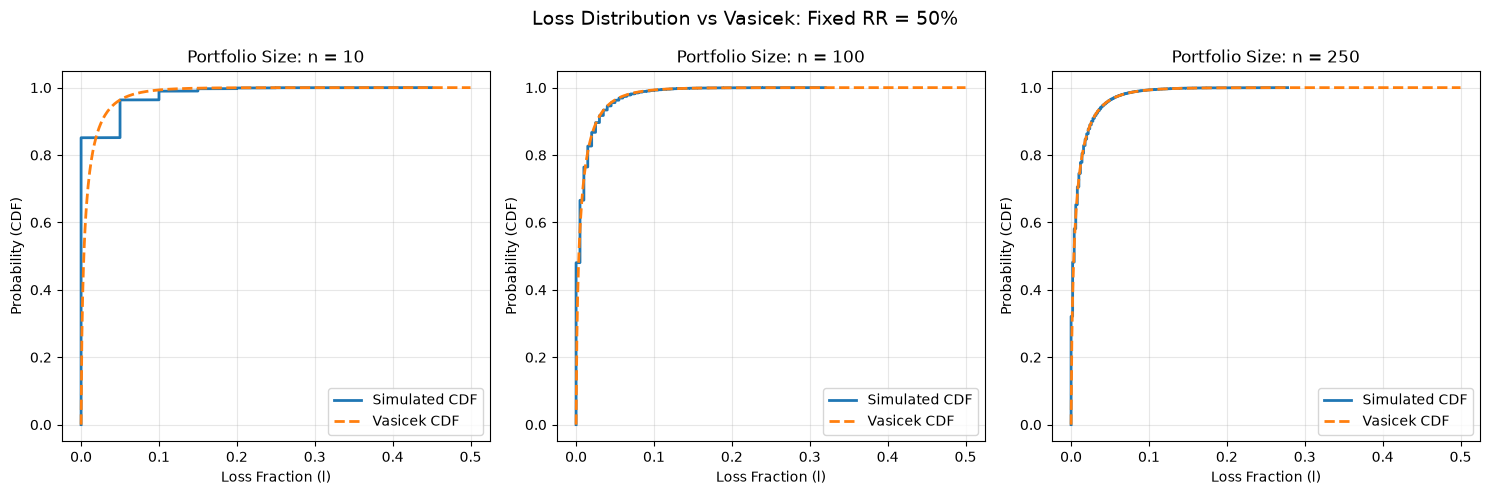

In [13]:
PD = 0.02
corr = 0.30
F = 100
M= 100000
RR = 0.50
LGD = 1 - RR
n_list = [10, 100, 250]
threshold = norm.ppf(PD)

def simulate_losses(n, M, lgd_value):
    Y = np.random.normal(size=(M, 1))
    Z = np.random.normal(size=(M, n))
    x = np.sqrt(corr) * Y + np.sqrt(1 - corr) * Z
    defaults = (x < threshold)
    total_defaults = defaults.sum(axis=1)
    loss_frac = (total_defaults * lgd_value) / n

    return loss_frac

def vasicek_cdf(l, PD, corr, LGD):
    q = np.clip(l / LGD, 1e-8, 1 - 1e-8)
    numerator = np.sqrt(1 - corr) * norm.ppf(q) - norm.ppf(PD)
    denominator = np.sqrt(corr)

    return norm.cdf(numerator / denominator)

plt.rcdefaults()
stats_rows = []
all_losses = {}
np.random.seed(42)
for n in n_list:
    losses = simulate_losses(n, M, LGD)
    all_losses[n] = losses

    stats_rows.append({
        'n'      : n,
        'Mean'   : np.mean(losses),
        'Std'    : np.std(losses),
        'Median' : np.median(losses),
        'P75'    : np.percentile(losses, 75),
        'P95'    : np.percentile(losses, 95),
        'P99'    : np.percentile(losses, 99)})

df_stats = pd.DataFrame(stats_rows)
print("Loss Distribution Summary:  Fixed RR = 50%")
display(df_stats.style.format({
    'Mean'  : '{:.4%}',
    'Std'   : '{:.4%}',
    'Median': '{:.2%}',
    'P75'   : '{:.2%}',
    'P95'   : '{:.2%}',
    'P99'   : '{:.2%}'}).hide())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Loss Distribution vs Vasicek: Fixed RR = 50%", fontsize=14)

for idx, n in enumerate(n_list):
    ax = axes[idx]
    losses = all_losses[n]
    sorted_losses = np.sort(losses)
    ecdf = np.arange(1, M + 1) / M
    l_grid = np.linspace(0, LGD, 500)
    vas = vasicek_cdf(l_grid, PD, corr, LGD)
    ax.plot(sorted_losses, ecdf, label='Simulated CDF', lw=2)
    ax.plot(l_grid, vas, label='Vasicek CDF', lw=2, linestyle='--')
    ax.set_title(f"Portfolio Size: n = {n}")
    ax.set_xlabel("Loss Fraction (l)")
    ax.set_ylabel("Probability (CDF)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


**Convergence to Vasicek:**
As portfolio size $n$ grows from 10 to 250, the simulated loss distribution
converges to the Vasicek asymptotic curve. For $n=10$ the distribution is
highly discrete since losses can only take values in $\{0\%, 5\%, 10\%, \dots\}$ producing a staircase ECDF that fits the Vasicek curve poorly. While for $n=250$ the two curves are nearly identical, confirming that the Vasicek approximation becomes valid as idiosyncratic risk diversifies away.

**Expected Loss is stable:**
Mean loss ≈ $1\%$ across all portfolio sizes, consistent with:
$E[\mathcal{L}] = PD \times LGD = 2\% \times 50\% = 1\%$

**Tail Risk decreases with $n$:**
Standard deviation falls from $2.78\%$ ($n=10$) to $1.80\%$ ($n=250$),
and P99 falls from $15\%$ to $8.8\%$. This reflects diversification of
idiosyncratic default risk, as $n$ grows, only the systematic risk component $\rho$ remains undiversifiable.

**Right-skewed distribution:**
For all $n$, median $\ll$ mean, most scenarios have near-zero losses, but rare correlated default events create a heavy right tail, cpused by correlated credit portfolios driven by the common factor $F_{\text{sys}}$.

#### b) Simulate the portfolios with recovery following a beta(0.5,0.5) distribution?
Instead of a fixed recovery rate, each defaulted credit $i$ recovers a
random fraction drawn from a $\text{Beta}(0.5, 0.5)$ distribution:

$$RR_i \sim \text{Beta}(0.5, 0.5), \qquad LGD_i = 1 - RR_i$$

The $\text{Beta}(0.5, 0.5)$ is **U-shaped** — recovery tends toward either
0 or 1, with mean $E[RR_i] = 0.5$. So expected loss is unchanged but
recovery variance increases tail dispersion for finite $n$.

Loss Distribution Summary:  RR ~ Beta(0.5, 0.5)


n,Mean,Std,Median,P75,P95,P99
10,1.0045%,3.2046%,0.00%,0.00%,8.78%,15.77%
100,0.9939%,1.9456%,0.03%,1.13%,4.56%,9.41%
250,1.0074%,1.8701%,0.35%,1.14%,4.39%,9.26%


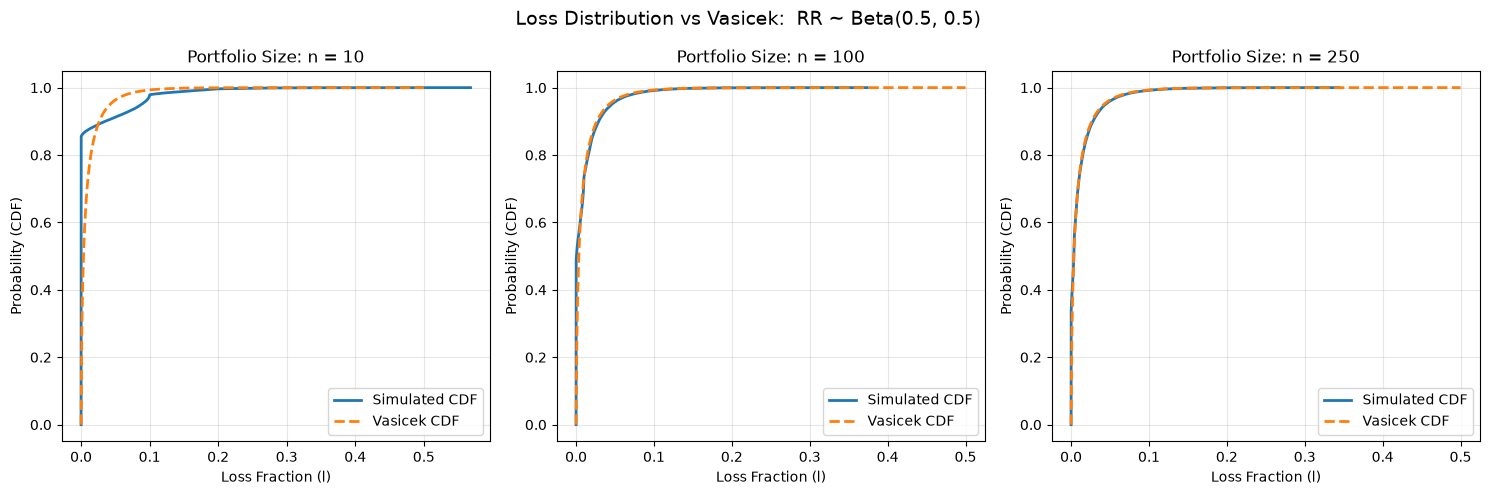

In [14]:
def simulate_losses_beta_fast(n, M):
    Y = np.random.normal(size=(M, 1))
    Z = np.random.normal(size=(M, n))
    x = np.sqrt(corr) * Y + np.sqrt(1 - corr) * Z

    defaults = (x < threshold).astype(int)
    rr_matrix = np.random.beta(0.5, 0.5, size=(M, n))
    lgd_matrix = 1 - rr_matrix
    scenario_losses = (defaults * lgd_matrix).sum(axis=1)
    loss_fract = scenario_losses / n

    return loss_fract

stats_rows_b = []
all_losses_b = {}
np.random.seed(42)

for n in n_list:
    losses = simulate_losses_beta_fast(n, M)
    all_losses_b[n] = losses
    stats_rows_b.append({
        'n'      : n,
        'Mean'   : np.mean(losses),
        'Std'    : np.std(losses),
        'Median' : np.median(losses),
        'P75'    : np.percentile(losses, 75),
        'P95'    : np.percentile(losses, 95),
        'P99'    : np.percentile(losses, 99),
    })

df_stats_b = pd.DataFrame(stats_rows_b)
print("Loss Distribution Summary:  RR ~ Beta(0.5, 0.5)")
display(df_stats_b.style.format({
    'Mean'  : '{:.4%}',
    'Std'   : '{:.4%}',
    'Median': '{:.2%}',
    'P75'   : '{:.2%}',
    'P95'   : '{:.2%}',
    'P99'   : '{:.2%}'}).hide())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(" Loss Distribution vs Vasicek:  RR ~ Beta(0.5, 0.5)", fontsize=14)

for idx, n in enumerate(n_list):
    ax = axes[idx]
    losses = all_losses_b[n]
    sorted_losses = np.sort(losses)
    ecdf = np.arange(1, M + 1) / M
    l_grid = np.linspace(0.00, 0.50, 500)
    vas = vasicek_cdf(l_grid, PD, corr, LGD)
    ax.plot(sorted_losses, ecdf, label='Simulated CDF', lw=2)
    ax.plot(l_grid, vas, label='Vasicek CDF', lw=2, linestyle='--')
    ax.set_title(f"Portfolio Size: n = {n}")
    ax.set_xlabel("Loss Fraction (l)")
    ax.set_ylabel("Probability (CDF)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

**Expected loss unchanged:**
Mean loss ≈ $1\%$ across all $n$, identical to Part a). This confirms that
since $E[\text{Beta}(0.5, 0.5)] = 0.5$, expected loss is preserved:
$E[\mathcal{L}] = PD \times E[LGD] = 2\% \times 50\% = 1\% $

**Higher variance and fatter tails vs Part a):**
Comparing Std across both parts: Stochastic recovery adds extra variance to losses, the U-shaped
$\text{Beta}(0.5, 0.5)$ pushes recovery toward 0 or 1, creating more extreme loss outcomes per defaulted credit.
Additionally effect diminishes as $n$ grows.
Increase in Std between Part a) and Part b) is largest for $n=10$
(+0.42%) and smallest for $n=250$ (+0.07%). As $n \to \infty$, iid
recovery noise diversifies away, only systematic default correlation
$\rho$ remains undiversifiable.

**Vasicek fit improves with stochastic recovery:**
The discrete jumps visible in Part a) disappear in Part b) because random recovery makes losses continuous rather than discrete. By $n=100$ the Simulated CDF nearly perfectly matches the Vasicek curve.

